In [ ]:
# =============================================================================
# IMPORTS & USER PARAMETERS
# =============================================================================
# Standard scientific stack: numpy (numerics), matplotlib (plotting),
# pandas (data frames), scipy.optimize.curve_fit (not used in final version
# but kept for potential future fitting tasks).
# termcolor is used to colour terminal progress output.
#
# USER PARAMETERS — edit these before running:
#   date_savename : date string prepended to every output file name
#   save_path     : directory where figures and CSVs are written
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from termcolor import colored
from matplotlib import cm
%matplotlib inline
import pandas as pd
from scipy.optimize import curve_fit
from tkinter import Tk, filedialog


############################################
#### Set parameters 

date_savename = '260827' # enter the date of the experiment you want to analyze (e.g. 260827)
save_path = "./output/FigS4/" # enter the path where you want to save the results


In [ ]:
# =============================================================================
# PHYSICS MODEL — Stokes sedimentation of a spherical GUV
# =============================================================================
# Two variants of the same underlying physics:
#
#   free_fall()
#       Full analytical solution including the transient exponential term that
#       describes the approach to terminal velocity.  For GUVs in aqueous media
#       under gravity this transient is negligible (τ ≈ microseconds), but the
#       term is kept for mathematical completeness.
#       Reference: Bartelmann, Theoretical Physics 1 (Heidelberg lecture notes)
#
#   free_fall_endvelocity()
#       Simplified version that skips the transient and uses only the terminal-
#       velocity term  x(t) = x0 − v_E · t.  Computationally cheaper and
#       equivalent for all practical time scales of the experiment.
#
# Both functions use the same force balance:
#   Net downward force  F_net = (ρ_GUV − ρ_medium) · (4/3)π r³ · g
#   Stokes drag         F_R   = 6π η r v
#   Terminal velocity   v_E   = F_net / (6π η r)
#
# Parameters (all in SI units unless stated otherwise):
#   x0         : initial height of the GUV above the bottom [m]
#   v0         : initial velocity (0 for a GUV at rest) [m/s]
#   g          : gravity multiplier (1 = Earth gravity; >1 = centrifuge)
#   r          : GUV radius [m]
#   visc       : dynamic viscosity of outer medium [mPa·s]
#   rho_guv    : effective density of the GUV [kg/m³]
#   rho_medium : density of the outer medium [kg/m³]
#   t          : time [s]
# Returns:
#   x_t        : predicted height at time t [m], converted to mm upstream
# =============================================================================

def free_fall(x0, v0, g, r, visc, rho_guv, rho_medium, t):
    """ x0:         starting height
        v0:         starting velocity
        g:          gravitational acceleration
        r :         radius of vesicle
        visc:       viscosity of outer medium
        rho_guv:    mass density of GUV
        rho_medium: mass density of medium
    """
    
    #### Gravitational acceleration g
    #### Change prefactor to simulate centrifugation
    Fg = g * 9.80665 # in m/s^2
    
    #### Stokes law: 
    #### F_R = 6*pi*radius*viscosity*velocity, 
    #### K = F_R/v
    K = 6 * np.pi*r*visc
    
    #### Free fall of sphere of radius r with density rho_guv in medium with density rho_medium
    #### F_down = F_gravity-F_buoyancy=(density_GUV-density_medium)* (4/3) * pi * r^3 * g
    #### A = F_down/g
    A = (rho_guv-rho_medium)*(4/3)*np.pi*(r**3)
    
    #### End velocity 
    v_E = A * Fg/K
    
    #### Position at time t
    x_t = x0 - (v_E*t) + (v0+v_E)*(v_E/Fg)*(1-np.exp(-Fg*t/v_E))
    #### According to Bartelmann Theoretical Physics 1 script: https://heibox.uni-heidelberg.de/f/7423ef45990149818ef9/
    
    return x_t


def free_fall_endvelocity(x0, v0, g, r, visc, rho_guv, rho_medium, t):
    """ x0:         starting height
        v0:         starting velocity
        r :         radius of vesicle
        visc:       viscosity of outer medium
        rho_guv:    mass density of GUV
        rho_medium: mass density of medium
    """
    
    #### Gravitational acceleration g
    Fg = g * 9.80665 # in m/s^2
    
    #### Stokes law: 
    #### F_R = 6*pi*radius*viscosity*velocity, 
    #### K = F_R/v
    K = 6*np.pi*r*visc
    
    #### Free fall of sphere of radius r with density rho_guv in medium with density rho_medium
    #### F_down = F_gravity-F_buoyancy=(density_GUV-density_medium)* (4/3) * pi * r^3 * g
    #### A = F_down/g
    A = (rho_guv-rho_medium)*(4/3)*np.pi*(r**3)
    
    #### End velocity 
    v_E = A*Fg/K
    
    #### Position at time t
    x_t = x0 - (v_E*t)
    #### According to Bartelmann Theoretical Physics 1 script: https://heibox.uni-heidelberg.de/f/7423ef45990149818ef9/
    #### This time without the complicated exponential
    
    
    return x_t


In [ ]:
# =============================================================================
# EXPERIMENT PARAMETER FACTORY — exp_parameters()
# =============================================================================
# Bundles all physical constants and experimental settings for a single
# simulation run into one tuple that the downstream functions consume.
#
# Sugar solutions used as inner (GUV lumen) and outer media:
#   'raff'  → raffinose   (ρ = 1058 kg/m³, η = 1.455 mPa·s)
#   'sucr'  → sucrose     (ρ = 1032 kg/m³, η = 1.156 mPa·s)
#   'gluc'  → glucose     (ρ = 1023 kg/m³, η = 1.073 mPa·s)
#
# ACCUM_FACTOR:
#   Multiplicative correction to the inner-medium density that accounts for
#   the accumulation of sugar inside the GUV lumen over time.
#   ACCUM_FACTOR = 1.00  → GUV lumen density equals bulk inner-medium density
#   ACCUM_FACTOR > 1.00  → GUV is denser (has accumulated solute)
#   The 0.696 offset represents the density contribution of the lipid membrane.
#
# GUV size distribution (Normalized_values):
#   Three options are provided (select by uncommenting):
#   1. Unwashed GUVs  — from Fig. 2e experimental data
#   2. Washed GUVs    — from Figs. 3–5 experimental data  (currently commented)
#   3. Uniform        — for testing / sensitivity analysis (currently commented)
#   Bin_centers are the midpoints of 5 µm-wide radius bins (2.5 … 47.5 µm).
#
# Starting heights (heightscale):
#   GUVs are placed at nb_starting_heights positions between the minimum and
#   maximum radius and the channel/tube ceiling.
#   'random'  → uniform random sampling (introduces stochasticity)
#   'linear'  → evenly spaced (deterministic, for reproducibility)
#
# Geometry:
#   'channel' → x0 = 0.4 mm  (µ-slide channel used in most experiments)
#   'tube'    → x0 = 20 mm   (Eppendorf tube / centrifuge geometry)
#
# Returns a tuple:
#   (radii_folded_list, time, heightscale, x0, v0, g, visc, rho_guv, rho_medium)
# =============================================================================
def exp_parameters(OUTERMED, INNERMED='raff', TUBE_OR_CHANNEL='channel', HEIGHTSCALE='random', TIMEFRAME='30min', ACCUM_FACTOR=1.00):



    # GUV size distribution from unwashed GUV probes, calculated from experimental data main Fig. 2e
    Normalized_values = [0.57252395,  0.24960104, 0.11259791, 0.0504613,  0.01123156, 0.00358424, 0,0,0,0]


    # GUV size distribution from washed GUV probes, calculated from experimental data main Figs. 3-5
    #Normalized_values =  [0.2280762271435444, 0.38845143652251807, 0.2381046847038606, 0.09364016372770417, 0.034976289860811645, 0.012216417641309282, 0.0027518028126849742, 0.0008097627395173214, 0.0004903563255966001, 0.00048285852245292133]


    # equal size distriubtion, hypothetical, for testing purposes
    #Normalized_values = [0.1,  0.1, 0.1, 0.1,  0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
    


    Number_of_GUVs = 100   
    Bin_centers =  [ 2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5, 42.5, 47.5]
    frequ_radii = Number_of_GUVs * np.array(Normalized_values) 


    radii = np.round(frequ_radii).astype(int)


    radii_folded_list = []
    for i in range(len(Bin_centers)):
        freq = int(frequ_radii[i])
        for f in range(freq):
            radii_folded_list.append(Bin_centers[i])
            
    

    nb_starting_heights = 80

    min_radius = Bin_centers[0]
    max_radius = Bin_centers[-1] #50 # in um
    
    g = 1
    v0 = 0
    rho_raff = 1058
    rho_sucr = 1032
    rho_gluc = 1023

    

    visc_gluc = 1.073 
    visc_suc = 1.156 
    visc_raff = 1.455 

    x0_channel = 0.0004
    x0_tube = 0.020 # in meters

    if INNERMED == 'raff':
        rho_guv = ACCUM_FACTOR * rho_raff + 0.696
    if INNERMED == 'sucr':
        rho_guv = ACCUM_FACTOR * rho_sucr + 0.696
    if INNERMED == 'gluc':
        rho_guv = ACCUM_FACTOR * rho_gluc + 0.696

    

    if OUTERMED == 'raff':
        rho_medium = rho_raff
        visc = visc_raff
    if OUTERMED == 'sucr':
        rho_medium = rho_sucr
        visc = visc_suc
    if OUTERMED == 'gluc':  
        rho_medium = rho_gluc
        visc = visc_gluc
        
    if TUBE_OR_CHANNEL == 'tube':
        x0 = x0_tube
    if TUBE_OR_CHANNEL == 'channel':
        x0 = x0_channel

    if TIMEFRAME == '30min':
        time = np.linspace(0,1800,1800)  
    if TIMEFRAME == '3.5h':
        time = np.linspace(0,12600,12600) 
    if TIMEFRAME == '24h': 
        time = np.linspace(0,86400,86400)  # in seconds

    
    randomheights = np.random.uniform(min_radius*10**-6, x0-max_radius*10**-6, nb_starting_heights) # in m
    linearheights = np.linspace(min_radius*10**-6, x0-max_radius*10**-6, nb_starting_heights)

    if HEIGHTSCALE == 'random':
        heightscale = randomheights
    elif HEIGHTSCALE == 'linear':
        heightscale = linearheights



    
    return radii_folded_list, time, heightscale, x0, v0, g, visc, rho_guv, rho_medium

In [ ]:
# =============================================================================
# SIMULATION CORE — get_arrival_times()
# =============================================================================
# Runs the sedimentation model for three buffer conditions simultaneously and
# returns a DataFrame with cumulative arrival statistics for each condition.
#
# Algorithm (per condition):
#   1. For every (radius, starting_height) pair, integrate the trajectory
#      x(t) using free_fall() and record the first time x(t) < 0, i.e. the
#      moment the GUV reaches the glass bottom.
#   2. Convert arrival times from seconds to minutes.
#   3. Bin arrival times into 30 equally spaced bins spanning [0, t_max].
#   4. Compute the cumulative sum → cumulative arrival histogram.
#
# The three conditions (EXP1/2/3_PARAMETERS) are typically the three outer
# media (raffinose, sucrose, glucose) run with the same ACCUM_FACTOR.
#
# Output DataFrame columns:
#   Condition        : label string (e.g. 'raff', 'sucr', 'gluc')
#   Arrival_Times_m  : list of individual arrival times [min]
#   Cumulative_Counts: cumulative histogram values (30 bins)
#   Bin_Centers_m    : bin centre positions [min]
#   Right_Bin_Edge   : right edge of each bin (used as the x-axis in
#                      comparison plots, matching experimental time points)
# =============================================================================

# Collect arrival times from 3 simulations for each condition
def get_arrival_times(EXP1_PARAMETERS, EXP2_PARAMETERS, EXP3_PARAMETERS, savename):
    

    colors = ["#585858", "#9c9c9c", "#e0e0e0"]
    
    all_conditions_df = pd.DataFrame()
    # Iterate through each condition

    radii1to3 = [EXP1_PARAMETERS[0], EXP2_PARAMETERS[0], EXP3_PARAMETERS[0]]
    time1to3 = [EXP1_PARAMETERS[1], EXP2_PARAMETERS[1], EXP3_PARAMETERS[1]]
    heightscale1to3 = [EXP1_PARAMETERS[2], EXP2_PARAMETERS[2], EXP3_PARAMETERS[2]]
    x01to3 = [EXP1_PARAMETERS[3], EXP2_PARAMETERS[3], EXP3_PARAMETERS[3]]
    v01to3 = [EXP1_PARAMETERS[4], EXP2_PARAMETERS[4], EXP3_PARAMETERS[4]]
    g1to3 = [EXP1_PARAMETERS[5], EXP2_PARAMETERS[5], EXP3_PARAMETERS[5]]
    visc1to3 = [EXP1_PARAMETERS[6], EXP2_PARAMETERS[6], EXP3_PARAMETERS[6]]
    rho_guv1to3 = [EXP1_PARAMETERS[7], EXP2_PARAMETERS[7], EXP3_PARAMETERS[7]]
    rho_medium1to3 = [EXP1_PARAMETERS[8], EXP2_PARAMETERS[8], EXP3_PARAMETERS[8]]

    for k in [0,1,2]:
        cond_name = savename[k]
        g = g1to3[k]
        x0 = x01to3[k]
        radii = radii1to3[k]
        time = time1to3[k]
        heightscale = heightscale1to3[k]
        v0 = v01to3[k]
        visc = visc1to3[k]
        rho_inner = rho_guv1to3[k]
        rho_medium = rho_medium1to3[k]

        arrival_time_list = []

        # Calculate the arrival time list for each g condition
        for radius in radii:
            r = radius * 1e-06  # in m
            for z in heightscale:
                y_data = {
                    'Radius': radius,
                    'Initial_Height': z,
                    'Time': time,
                    'Height': [1e+03 * free_fall(z, v0, g, r, visc, rho_inner, rho_medium, timepoint) for timepoint in time]
                }
                entry = pd.DataFrame(y_data)
                entry['Height'] += x0
                negative_time = entry.loc[entry['Height'] < 0, 'Time'].min()
                if not pd.isna(negative_time):
                    arrival_time_list.append(negative_time)

        # Convert times to hours
        arrival_time_list_mins = [time / 60 for time in arrival_time_list]

        # Plot cumulative histogram
        bins = np.linspace(0, entry['Time'].max() / 60, 31)
        hist_values, bin_edges = np.histogram(arrival_time_list_mins, bins=bins)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        cumulative_hist_values = np.cumsum(hist_values)

        df = pd.DataFrame({
            'Condition': cond_name,
            'Arrival_Times_m': [arrival_time_list_mins],
            'Cumulative_Counts': [cumulative_hist_values],
            'Bin_Centers_m': [bin_centers],
            'Right_Bin_Edge': [bin_edges[1:]]
        })

        all_conditions_df = pd.concat([all_conditions_df, df], ignore_index=True)
    

    return all_conditions_df





In [ ]:
# =============================================================================
# MONTE CARLO AVERAGING — calc_sim_arrival_mean_std()
# =============================================================================
# Because starting heights are drawn randomly, each call to get_arrival_times()
# yields a slightly different cumulative curve.  This function runs 6
# independent replicates and returns the mean ± std across them, which gives a
# stable, noise-reduced simulation result for comparison with experiment.
#
# Normalization:
#   After averaging, every condition's cumulative curve is divided by the
#   global maximum across all three conditions so that the y-axis runs from
#   0 to 1.  This matches the normalization applied to the experimental data.
#
# Input:
#   ACC_FAC_LIST : list of accumulation factors to evaluate.
#                  Only the first element is used inside this function
#                  (the outer loop in the main cell iterates over the list).
#
# Output DataFrame columns:
#   Sim_Condition  : buffer label
#   Sim_Time_Point : right bin edge [min] — the x-axis for plotting
#   Sim_Mean       : normalized mean cumulative fraction across 6 runs
#   Sim_Std        : standard deviation across 6 runs
# =============================================================================
def calc_sim_arrival_mean_std(ACC_FAC_LIST):

    sim_results_df = pd.DataFrame({
            'Sim_Condition': [],
            'Sim_Time_Point': [],
            'Sim_Mean': [],
            'Sim_Std': []
        })

    

    for ACCUM_FACTOR in ACC_FAC_LIST:
        df_1 = get_arrival_times(exp_parameters('raff', ACCUM_FACTOR=ACCUM_FACTOR), exp_parameters('sucr', ACCUM_FACTOR=ACCUM_FACTOR), exp_parameters('gluc', ACCUM_FACTOR=ACCUM_FACTOR), ['raff', 'sucr', 'gluc'])
        df_2 = get_arrival_times(exp_parameters('raff', ACCUM_FACTOR=ACCUM_FACTOR), exp_parameters('sucr', ACCUM_FACTOR=ACCUM_FACTOR), exp_parameters('gluc', ACCUM_FACTOR=ACCUM_FACTOR), ['raff', 'sucr', 'gluc'])
        df_3 = get_arrival_times(exp_parameters('raff', ACCUM_FACTOR=ACCUM_FACTOR), exp_parameters('sucr', ACCUM_FACTOR=ACCUM_FACTOR), exp_parameters('gluc', ACCUM_FACTOR=ACCUM_FACTOR), ['raff', 'sucr', 'gluc'])
        df_4 = get_arrival_times(exp_parameters('raff', ACCUM_FACTOR=ACCUM_FACTOR), exp_parameters('sucr', ACCUM_FACTOR=ACCUM_FACTOR), exp_parameters('gluc', ACCUM_FACTOR=ACCUM_FACTOR), ['raff', 'sucr', 'gluc'])
        df_5 = get_arrival_times(exp_parameters('raff', ACCUM_FACTOR=ACCUM_FACTOR), exp_parameters('sucr', ACCUM_FACTOR=ACCUM_FACTOR), exp_parameters('gluc', ACCUM_FACTOR=ACCUM_FACTOR), ['raff', 'sucr', 'gluc'])
        df_6 = get_arrival_times(exp_parameters('raff', ACCUM_FACTOR=ACCUM_FACTOR), exp_parameters('sucr', ACCUM_FACTOR=ACCUM_FACTOR), exp_parameters('gluc', ACCUM_FACTOR=ACCUM_FACTOR), ['raff', 'sucr', 'gluc'])


        colors = ["#585858", "#9c9c9c", "#e0e0e0"]

        # Compute average and std for each condition across df_1 to 6
        mean_counts_per_condition = []
        std_counts_per_condition = []
        for cond_idx in range(3):  # 3 conditions per df
            cond_counts = [
                np.array(df_1.loc[cond_idx, 'Cumulative_Counts']),
                np.array(df_2.loc[cond_idx, 'Cumulative_Counts']),
                np.array(df_3.loc[cond_idx, 'Cumulative_Counts']),
                np.array(df_4.loc[cond_idx, 'Cumulative_Counts']),
                np.array(df_5.loc[cond_idx, 'Cumulative_Counts']),
                np.array(df_6.loc[cond_idx, 'Cumulative_Counts'])
            ]
            right_bin_edge = df_1.loc[cond_idx, 'Right_Bin_Edge']  # Assuming all have the same bin edges

            bin_centers = df_1.loc[cond_idx, 'Bin_Centers_m']  # Assuming all have the same bin centers
            cond_counts_arr = np.stack(cond_counts)
            mean_counts_per_condition.append(np.mean(cond_counts_arr, axis=0))
            std_counts_per_condition.append(np.std(cond_counts_arr, axis=0))

            
            # accumulate means/stds and normalize after last condition is processed
            if '__accum_means__' not in locals():
                __accum_means__ = []
                __accum_stds__ = []
            __accum_means__.append(mean_counts_per_condition[-1])
            __accum_stds__.append(std_counts_per_condition[-1])

            # once all conditions have been processed, normalize to the global max
            if cond_idx == 2:
                global_max = max(np.max(arr) for arr in __accum_means__) if len(__accum_means__) > 0 else 1.0
                if global_max == 0:
                    global_max = 1.0
                for i in range(len(mean_counts_per_condition)):
                    mean_counts_per_condition[i] = mean_counts_per_condition[i] / global_max
                    std_counts_per_condition[i] = std_counts_per_condition[i] / global_max


                
        # Create a dataframe from mean_counts and std_counts
        # Fill sim_results_df for each condition
        for i in range(3):
            sim_results_df = pd.concat([
                sim_results_df,
                pd.DataFrame({
                    'Sim_Condition': [df_1.loc[i, 'Condition']] * len(right_bin_edge),
                    'Sim_Time_Point': right_bin_edge,
                    'Sim_Mean': mean_counts_per_condition[i],
                    'Sim_Std': std_counts_per_condition[i]
                    })
                ], ignore_index=True)



        return sim_results_df

In [ ]:
# =============================================================================
# MAIN EXECUTION — Least-Squares Search Over Accumulation Factors
# =============================================================================
# Goal: find the ACCUM_FACTOR that makes the simulated cumulative arrival
# curves best match the experimental data from Fig. 2e.
#
# Steps:
#   1. Load experimental data (Condition, Time_Point, Mean, Std) from CSV.
#      The CSV must be placed in the same directory as this notebook, or the
#      path must be adjusted.
#   2. For each candidate ACCUM_FACTOR in ACC_FAC_LIST:
#        a. Run calc_sim_arrival_mean_std() → normalized sim curves.
#        b. compute_least_squares() merges sim and exp on matching time points
#           and computes the sum-of-squared-errors (SSE) per condition and in
#           total.
#   3. Collect all SSE values in lsq_results_df for inspection and plotting.
#
# compute_least_squares():
#   Merges experimental and simulated data on matching time points (inner join)
#   to handle any time-point mismatches gracefully, then returns:
#     SSE per condition  + "Total_Error" = sum of per-condition SSEs
#
# USER PARAMETERS:
#   csv_path     : path to the experimental CSV file
#   ACC_FAC_LIST : range of accumulation factors to test (step 0.01 recommended)
#   save_path    : output directory for figures
# =============================================================================


# -----------------------------
# USER INPUT
# -----------------------------
csv_path = 'input_Fig2e_experimental_data_for_comparison.csv'
ACC_FAC_LIST = [1.0, 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1, 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17, 1.18, 1.19, 1.2]

save_path = "./"               # figure saving location
# -----------------------------


# -----------------------------------------
# LOAD EXPERIMENTAL DATA
# -----------------------------------------
exp_results_df = pd.read_csv(csv_path)

conditions = exp_results_df['Condition'].unique()

# -----------------------------------------
# FUNCTION: compute least squares
# -----------------------------------------
def compute_least_squares(exp_df, sim_df):
    """
    Computes sum of squared errors per condition.
    Matches timepoints automatically via merge.
    """
    lsq_per_condition = {}

    for cond in exp_df['Condition'].unique():
        exp_c = exp_df[exp_df['Condition'] == cond][['Time_Point', 'Mean']]
        sim_c = sim_df[sim_df['Sim_Condition'] == cond][['Sim_Time_Point', 'Sim_Mean']]
        
        # merge on timepoints
        merged = exp_c.merge(sim_c, left_on='Time_Point', right_on='Sim_Time_Point', how='inner')

        # compute SSE
        sse = np.sum((merged['Mean'] - merged['Sim_Mean'])**2)
        lsq_per_condition[cond] = sse

    lsq_per_condition["Total_Error"] = sum(lsq_per_condition.values())
    return lsq_per_condition


# -----------------------------------------
# LOOP OVER ACC FACTORS
# -----------------------------------------
all_results = []

for acc_fac in ACC_FAC_LIST:
    print(colored(f"Calculating for ACC_FAC={acc_fac}", "cyan"))
    sim_results_df = calc_sim_arrival_mean_std(ACC_FAC_LIST=[acc_fac])

    
    errors = compute_least_squares(exp_results_df, sim_results_df)
    errors["ACC_FAC"] = acc_fac

    all_results.append(errors)

# Convert results to a DataFrame
lsq_results_df = pd.DataFrame(all_results)
lsq_results_df = lsq_results_df[['ACC_FAC'] + list(conditions) + ["Total_Error"]]

print("\n=== LEAST SQUARE RESULTS ===\n")
print(lsq_results_df.to_string(index=False))




Calculating for ACC_FAC=1.0
Calculating for ACC_FAC=1.01
Calculating for ACC_FAC=1.02
Calculating for ACC_FAC=1.03


KeyboardInterrupt: 

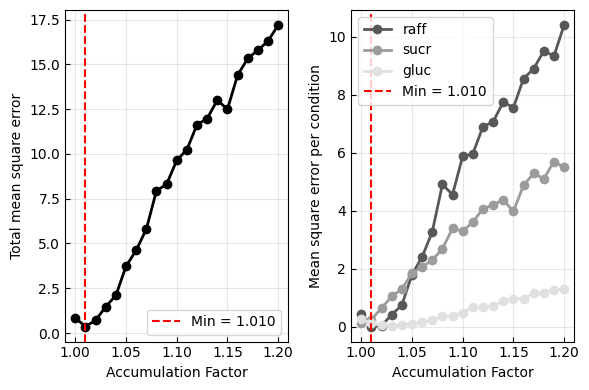

In [ ]:
# =============================================================================
# RESULT VISUALIZATION — Error vs. Accumulation Factor
# =============================================================================
# Two-panel figure:
#   Left  (ax1): Total SSE across all three conditions vs. ACCUM_FACTOR.
#                A vertical red dashed line marks the best-fit value.
#   Right (ax2): Per-condition SSE vs. ACCUM_FACTOR, colour-coded by medium.
#                Helps identify whether the best fit is driven by one condition
#                or balanced across all three.
#
# The best accumulation factor corresponds to the minimum total SSE and
# represents the ratio by which the lumen density exceeds the bulk inner-
# medium density, i.e. the degree of solute accumulation inside the GUV.
# =============================================================================
# Plot total error and error per condition for all accumulation factors

mask = (lsq_results_df['ACC_FAC'] >= 1.0) & (lsq_results_df['ACC_FAC'] <= 2.0)
filtered_df = lsq_results_df[mask]

best_acc_fac = filtered_df.loc[filtered_df['Total_Error'].idxmin(), 'ACC_FAC']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 4))

# Plot 1: Total Error vs ACC_FAC
ax1.plot(filtered_df['ACC_FAC'], filtered_df['Total_Error'], 
         'o-', color='black', linewidth=2, markersize=6)
ax1.axvline(x=best_acc_fac, color='red', linestyle='--', 
            label=f'Min = {best_acc_fac:.3f}')
ax1.set_xlabel('Accumulation Factor')
ax1.set_ylabel('Total mean square error')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.tick_params(direction='in')


colors_cond = {"raff": "#585858", "sucr": "#9c9c9c", "gluc": "#e0e0e0"}
for condition in conditions:
    ax2.plot(filtered_df['ACC_FAC'], filtered_df[condition], 
             'o-', color=colors_cond[condition], label=condition, 
             linewidth=2, markersize=6)

ax2.axvline(x=best_acc_fac, color='red', linestyle='--', 
            label=f'Min = {best_acc_fac:.3f}')
ax2.set_xlabel('Accumulation Factor')
ax2.set_ylabel('Mean square error per condition')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left')
ax2.tick_params(direction='in')

plt.tight_layout()
plt.savefig(f'{save_path}/{date_savename}_Error_vs_ACC_FAC.pdf', dpi=300)
plt.show()

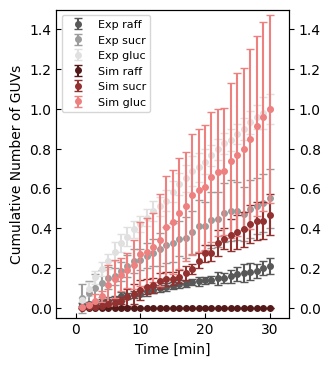

In [ ]:
# =============================================================================
# VALIDATION PLOT — Simulation vs. Experimental Cumulative Arrivals
# =============================================================================
# Overlay of experimental (grey tones, left y-axis) and simulated (red tones,
# right y-axis) cumulative arrival curves for the three buffer conditions.
# Both axes share the same scale [−0.05, 1.5] so that experiment and
# simulation can be compared visually.
#
# The simulation is re-run here across the full ACC_FAC_LIST so the curves
# shown correspond to the mean across all tested accumulation factors; in
# practice the caller should reduce ACC_FAC_LIST to the best-fit value to
# display the optimal match.
#
# Output: saved as PDF in save_path with the accumulation-factor range in the
# file name for traceability.
# =============================================================================
# Load the experimental data from CSV
exp_results_df = pd.read_csv('input_Fig2e_experimental_data_for_comparison.csv')
sim_results_df = calc_sim_arrival_mean_std(ACC_FAC_LIST=ACC_FAC_LIST)


# Plot the experimental data alongside the simulation results
fig, ax1 = plt.subplots(figsize=(3, 4))
ax2 = ax1.twinx()

# Plot experimental data
conditions = exp_results_df['Condition'].unique()
colors_exp = {"raff": "#585858", "sucr": "#9c9c9c", "gluc": "#e0e0e0"}
colors_sim = {"raff": "#541A1A", "sucr": "#933030", "gluc": "#ee8080"}

for condition in conditions:
    exp_cond_data = exp_results_df[exp_results_df['Condition'] == condition]
    ax1.errorbar(exp_cond_data['Time_Point'], exp_cond_data['Mean'], 
                yerr=exp_cond_data['Std'], fmt='o', color=colors_exp[condition], 
                label=f'Exp {condition}', capsize=3, markersize=4)
    ax1.set_ylim(-0.05, 1.5)
    sim_cond_data = sim_results_df[sim_results_df['Sim_Condition'] == condition]
    ax2.errorbar(sim_cond_data['Sim_Time_Point'], sim_cond_data['Sim_Mean'], 
                yerr=sim_cond_data['Sim_Std'], fmt='o', color=colors_sim[condition], 
                label=f'Sim {condition}', capsize=3, markersize=4)
    ax2.set_ylim(-0.05, 1.5)


ax1.set_xlabel('Time [min]')
ax1.set_ylabel('Cumulative Number of GUVs')
ax1.set_xlim(-3, 33)
ax1.set_xticks([0, 10, 20, 30])
ax1.tick_params(direction='in')
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, fontsize=8, loc='upper left')
plt.savefig(f'{save_path}/{date_savename}_Sim_vs_Experimental_arriving_GUVs_{ACC_FAC_LIST[0]}.pdf', dpi=300)
plt.show()

